# DAY 5  导数与梯度

## 导数的描述
导数描述的是函数在某个点的变化情况

函数值：being

导数：becoming

万物皆可流动，流的本身皆可以丈量

好的变化--> 发展

即使在静态的瞬间，宇宙都在呼吸

$h\to 0$

启示：
1. 方向比位置更重要；
2. 活在当下，但要看向未来；
3. 趋势大于现状。

数学世界最为性感的知识模块，用最为冷静的**极限**，定义了最为炽热的**变化**。

大模型工作的背后：求导 沿着负方向加速

### 牛顿 莱布尼茨

牛顿 物理学家  物体在某个点的速度？
莱布尼茨 哲学家 数学家  函数在某个点的斜率？

$\frac{0}{0}$

“微积分” ——> 瞬时变化率

莱布尼茨 $\frac{dx}{dy}$ $\int$

### 柯西与极限的严格化

数值计算code、梯度下降Algorithm  底层都是“极限”思想

柯西  最速下降法：沿着梯度反向走，每一步都让函数下降最快

加速度：如果速度在增加，距离对于时间的二阶导数
梯度是多变量函数的导数，它指向函数增长最快的方向

min --> 梯度反方向

计算机世界里面处理的永远不是物理运动而是优化问题

* ML：最小化损失函数

* DL：最小化交叉熵

* 推荐系统：最小化预测误差

* 量化交易：最大化交易和最小化风险

以上的本质都在求极值，必须用到导数和梯度

世界充满了变化，计算机充满了优化

CV Model Prediction

方向 敏感度  如果x变化一点点，y变化多少

Why 梯度？

模型参数太多  NNW 亿级参数 无法一个个调  需要一个方向 知道损失函数下降最快  梯度就是这个方向   对应参数往哪里调 调多少

梯度下降：$参数=参数-学习率×梯度$

CS 从数据中寻找规律
* 监督学习
* 无监督学习
* 强化学习
* 深度学习


## 导数：

$$f'(x)=\lim{\Delta x\to 0}\frac{f(x + \Delta x) - f(x)}{\Delta x}$$

## 偏导数：把其它变量当常数，只对其中一个求导（简单版）

$$ \frac{\partial f}{\partial x} = \lim_{\Delta x \to 0} \frac{f(x + \Delta x, y) - f(x, y)}{\Delta x} $$

## 梯度：把所有的偏导数放在一起成向量

key point：方向和大小

$$ \nabla f = \left[ \frac{\partial f}{\partial x}, \frac{\partial f}{\partial y}, \frac{\partial f}{\partial z}, \dots \right] $$

要让函数值下降最快，就要沿着负梯度方向走

## 求导法则：
* **常数**：$(C)' = 0$
* **幂函数**：$(x^n)' = nx^{n-1}$
* **指数函数**：$(e^x)' = e^x$
* **对数函数**：$(\ln x)' = \frac{1}{x}$
* **正弦函数**：$(\sin x)' = \cos x$
* **余弦函数**：$(\cos x)' = -\sin x$



运算法则：

* **加法**：$(f + g)' = f' + g'$
* **乘法**：$(fg)' = f'g + fg'$
* **除法**：$$\left( \frac{f}{g} \right)' = \frac{f'g - fg'}{g^2}$$
* **链式法则**：$(f(g(x)))' = f'(g(x)) \cdot g'(x)$


## 泰勒展开式

$$ f(x) = f(x_0) + f'(x_0)(x - x_0) + \frac{f''(x_0)}{2!}(x - x_0)^2 + \dots $$


In [2]:
#导数与梯度

import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif']=['SimHei']
plt.rcParams['axes.unicode_minus'] = False
print('Success!!!')

Success!!!


In [14]:
#数值求导

def f(x):return x**2
def f_prime(x):return 2^x
def num_deriv(func,x,h=1e-5):
    return (func(x+h) - func(x)) / h

for x in [0,1,2,3]:
    exact = f_prime(x)
    numeric = num_deriv(f,x)
    print(f'x={x}:解析={exact}，数值={numeric:.6f},误差={abs(exact-numeric):.2e}')

x=0:解析=2，数值=0.000010,误差=2.00e+00
x=1:解析=3，数值=2.000010,误差=1.00e+00
x=2:解析=0，数值=4.000010,误差=4.00e+00
x=3:解析=1，数值=6.000010,误差=5.00e+00


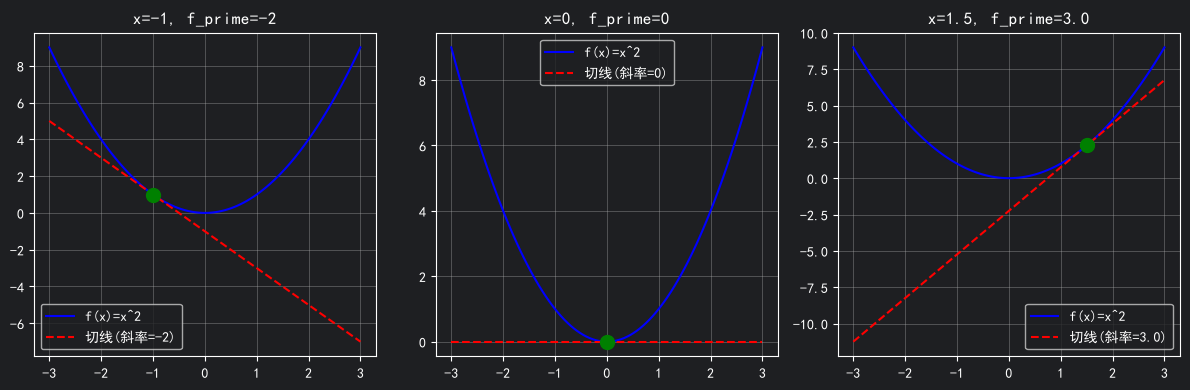

In [6]:
#可视化
x = np.linspace(-3,3,100)
y = x**2

fig,axes = plt.subplots(1, 3,figsize = (12,4))

for ax, x0 in zip(axes, [-1, 0, 1.5]):
    ax.plot(x, y, 'b-', label='f(x)=x^2')
    slope = 2*x0
    tangent = f(x0) + slope*(x - x0)
    ax.plot(x, tangent, 'r--', label=f'切线(斜率={slope})')
    ax.plot(x0, f(x0), 'go', markersize=10)
    ax.set_title(f'x={x0}, f_prime={slope}')
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [7]:
def f2(x,y):return x**2+3*x*y + y**2
def df_dx(x,y):return 2*x +3*y
def df_dy(x,y):return 3*x+2*y
def num_partial(func,x,y,h=1e-5,axis=0):
    if axis == 0:
        return (func(x+h,y) - func(x,y)) / h
    else:
        return (func(x,y+h) - func(x,y)) / h

x0,y0 =1,2
print(f'df/dx({x0},{y0})=解析={df_dx(x0,y0)},数值={num_partial(f2,x0,y0,axis=0):.6f}')
print(f'df/dx({x0},{y0})=解析={df_dx(x0,y0)},数值={num_partial(f2,x0,y0,axis=1):.6f}')
print(f'梯度 = [{df_dx(x0, y0)},{df_dy(x0,y0)}]')

df/dx(1,2)=解析=8,数值=8.000010
df/dx(1,2)=解析=8,数值=7.000010
梯度 = [8,7]


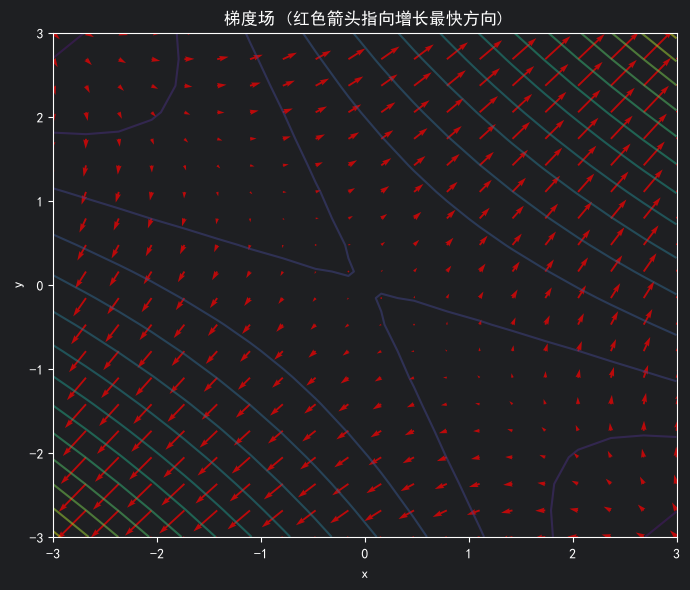

In [8]:
x =np.linspace(-3,3,20)
y =np.linspace(-3,3,20)

X,Y =np.meshgrid(x,y)
Z =X**2 +3*X*Y +Y**2
U = 2*X +3*Y
V = 3*X + 2*Y

fig,ax = plt.subplots(figsize = (7,6))
ax.contour(X,Y,Z,15,cmap='viridis',alpha=0.5)
ax.quiver(X, Y, U, V, color='red', alpha=0.7)
ax.set_title('梯度场 (红色箭头指向增长最快方向)')
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.tight_layout()
plt.show()

In [10]:
#梯度下降

def f3(x,y):return x**2+y**2
def grad_f3(x,y):return np.array([2*x,2*y])

pos = np.array([2.5,2.5])
lr =0.1
path = [pos.copy()]

for i in range(50):
    g = grad_f3(pos[0],pos[1])
    pos = pos -lr*g
    path.append(pos.copy())
    if i % 10 == 0:
        print(f'步{i}: pos={pos}, loss{f3(pos[0],pos[1]):.6f}')
print(f'最终: pos={pos}, loss{f3(pos[0],pos[1]):.8f}')


步0: pos=[2. 2.], loss8.000000
步10: pos=[0.21474836 0.21474836], loss0.092234
步20: pos=[0.02305843 0.02305843], loss0.001063
步30: pos=[0.00247588 0.00247588], loss0.000012
步40: pos=[0.00026585 0.00026585], loss0.000000
最终: pos=[3.56811923e-05 3.56811923e-05], loss0.00000000


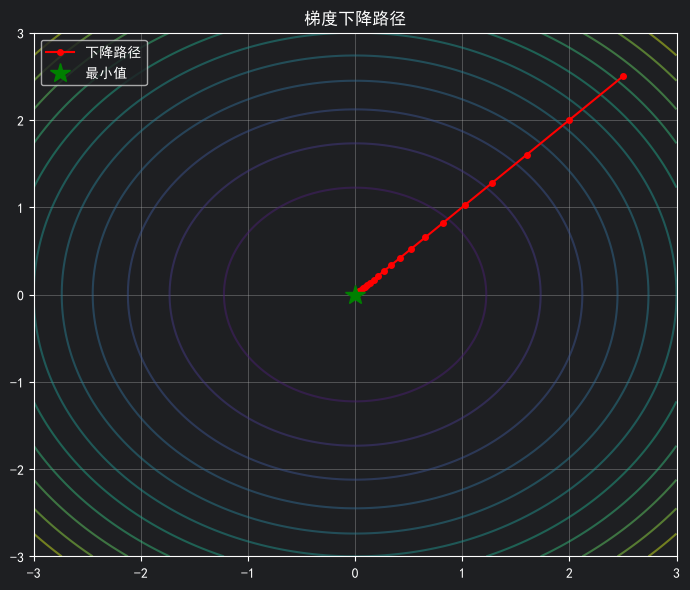

In [13]:
path = np.array(path)
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2

fig,ax = plt.subplots(figsize = (7,6))
ax.contour(X,Y,Z,15,cmap='viridis',alpha=0.5)
ax.plot(path[:,0],path[:,1], 'r.-',markersize=8,label='下降路径')
ax.plot(0,0,'g*',markersize=15,label='最小值')
ax.set_title('梯度下降路径')
ax.legend()
ax.grid(visible=True)
plt.tight_layout()
plt.show()